# 02a's capacity estimator: removing the binning bias, without changing the construct

`02a_triangles.ipynb` §2 estimates each participant's information-processing
**capacity** — how much structure a participant's own choice sequence
carries beyond what the task's hazard-driven autocorrelation already
explains — as a difference of two mutual-information (MI) terms,
`Ipast_subject - Ipast_stimulus`. That difference is *sequential* by
necessity, not by choice: the task's hazard rates are deliberately set away
from 0.5 (a switch is more or less likely depending on hazard tier, not a
coin flip), so inferring the hidden, slowly-switching generative state
requires integrating evidence across multiple trials — that is the whole
point of the task design. A subject's capacity is fundamentally about how
well they exploit that cross-trial structure, so it has to be measured from
a multi-trial quantity: `Ipast` is the MI between a single-trial evidence
"feature" and the *next three choices* (a "response word"), with the same
calculation on the raw stimulus sequence subtracted off as a baseline (so
predictability already built into the task itself isn't credited to the
participant). A single-trial `I(evidence; choice)` has no way to reflect any
of this — it's blind to trial order entirely — so it was never a candidate
estimator here, independent of how it's computed.

What *is* a real problem: `02a_triangles.ipynb` collapses the continuous
evidence to a single bit (left/right of the triangle midpoint) before
computing `Ipast`, and separately collapses hazard rate to 3 tiers. The
hazard binning is fine — hazard tier is a genuine 3-level experimental
condition, not a continuum coarsened for convenience — but the evidence
binning throws away real information, and (checked in §4 below) does so
asymmetrically: worse exactly when the true evidence-to-choice relationship
is smooth rather than step-like, which is precisely the distinction
`02a_triangles.ipynb` §7 is trying to draw.

This notebook builds and validates a binless replacement for that one step —
keeping `Ipast_subject - Ipast_stimulus`'s sequential, baseline-subtracted
construct completely intact — before deciding whether to adopt it:

1. **Bias correction** — keep the same binned calculation, but correct its
   plug-in MI for the well-characterized small-sample bias of
   histogram-based entropy estimators (Miller & Madow, 1955). Cheap, but
   (checked below) doesn't touch the actual problem.
2. **A binless estimator** — skip binning the continuous evidence, using a
   k-nearest-neighbor MI estimator (Kraskov, Stögbauer & Grassberger, 2004;
   the mixed continuous/discrete variant in Ross, 2014), applied to the same
   feature-word/response-word construct via the mutual-information chain
   rule.

Both are checked against exact ground truth — closed-form synthetic channels
(§4) and the project's own IB-optimal capacity-limited observer model (§5),
where the ground truth is computed analytically by `utilities/ib_core.py`
rather than simulated — before being applied to the real triangles dataset
(§6), where `02a_triangles.ipynb`'s downstream finding (lower capacity ↔ a
more step-like choice-probability curve) is also checked for whether it
depends on the fix used.

**Acronyms:** MI = mutual information. KSG = Kraskov–Stögbauer–Grassberger
(the nearest-neighbor MI estimator family used here). FSM = finite-state
machine (the discrete "belief ladder" model of a capacity-limited
decision-maker, from `utilities/ib_core.py`). LLR = log-likelihood ratio
(natural-log units, nats).

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.special import digamma
from scipy.spatial import cKDTree
from scipy.stats import norm, spearmanr
import matplotlib.pyplot as plt

plt.rcParams.update({"font.size": 12})

sys.path.insert(0, str(Path.cwd().parent / "utilities"))
from intuitions import (
    simulate_switching_sequence, emit_continuous, discretize_gaussian, bin_index,
    get_optimal_fsm, simulate_ladder_path,
)
from ib_core import fsm_scores

# categorical colors for the two candidate fixes, used consistently throughout
COLOR_PLUGIN    = "#2a78d6"  # naive (binned, uncorrected) plug-in MI
COLOR_PLUGIN_MM = "#eb6834"  # binned plug-in MI, Miller-Madow bias-corrected
COLOR_KSG       = "#1baf7a"  # continuous, k-nearest-neighbor MI (no binning)

print("setup complete")

setup complete


## 1. Building blocks: two general-purpose MI estimators

`plugin_mi` and `ksg_mi` estimate `I(X; Y)` from paired samples of a
continuous `X` and a discrete `Y`. They're generic — not specific to
"evidence" or "choice" — and are the two tools §2 uses to build the actual
capacity construct. Unit-tested here on nothing more than independent
random data, before being trusted for anything else.

- **`plugin_mi`** — the same histogram/plug-in calculation
  `02a_triangles.ipynb` uses for its `Ipast` capacity proxy: bin `x` into
  `n_bins` levels, build the joint frequency table with `y`, and compute MI
  directly from the empirical joint and marginal frequencies
  (`I = H(X) + H(Y) - H(X,Y)`). This is what a finite sample's raw
  frequencies say the true MI is, with no correction for the fact that
  frequencies estimated from limited data are systematically noisy.
- **`ksg_mi`** — a k-nearest-neighbor estimator (Ross, 2014, the mixed
  continuous-`X`/discrete-`Y` variant of Kraskov et al., 2004) that never
  bins `x`: for each trial, it finds how close that trial's `x` value is to
  its `k`-th nearest neighbor *within the same `y` category*, then counts
  how many trials of *any* category fall inside that same radius. Density
  is inferred locally and adaptively (implicitly finer bins where data are
  dense, coarser where sparse) rather than off a fixed grid, which is what
  lets it work at smaller sample sizes than a fixed-bin histogram.

`plugin_mi`'s optional `mm_correct` flag adds the Miller & Madow (1955)
bias correction to each entropy term: `H_corrected = H_plugin + (m - 1) /
(2 N ln 2)` bits, where `m` is the number of distinct symbol values actually
observed and `N` the trial count. This targets the leading-order term of the
plug-in estimator's bias (entropy is biased upward; MI, a difference of
entropies, is typically biased *downward* toward zero as a result) — it
doesn't remove all of the bias, but it removes the dominant,
well-characterized part.

In [2]:
def _entropy_bits(counts, mm_correct=False):
    '''Shannon entropy (bits) from a vector of category counts, optionally
    Miller-Madow bias-corrected.'''
    counts = np.asarray(counts, dtype=float)
    counts = counts[counts > 0]
    n = counts.sum()
    p = counts / n
    H = -np.sum(p * np.log2(p))
    if mm_correct:
        H += (len(counts) - 1) / (2 * n * np.log(2))
    return H


def plugin_mi(x, y, n_bins=2, mm_correct=False, bin_edges=None):
    '''Plug-in mutual information (bits) between continuous `x` and a
    discrete `y`, after binning `x` into `n_bins` equal-count (quantile)
    bins (or the given `bin_edges`). Set `mm_correct=True` for the
    Miller-Madow bias correction.'''
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=int)
    if bin_edges is None:
        bin_edges = np.unique(np.quantile(x, np.linspace(0, 1, n_bins + 1)))
    xb = np.clip(np.digitize(x, bin_edges[1:-1]), 0, len(bin_edges) - 2)

    nx, ny = xb.max() + 1, y.max() + 1
    joint = np.zeros((nx, ny))
    np.add.at(joint, (xb, y), 1)

    Hx = _entropy_bits(joint.sum(1), mm_correct)
    Hy = _entropy_bits(joint.sum(0), mm_correct)
    Hxy = _entropy_bits(joint.ravel(), mm_correct)
    return Hx + Hy - Hxy


def ksg_mi(x, y, k=3):
    '''KSG-family MI estimate (bits) between continuous `x` and discrete
    `y` (Ross, 2014, 'Mutual Information between Discrete and Continuous
    Data Sets', PLOS ONE). No binning of `x`: for each trial i, find the
    distance to its k-th nearest neighbor among the *other* trials sharing
    y_i's category, then count m_i, the number of trials of any category
    within that same radius.
    I(X;Y) = psi(N) - <psi(N_y)> + <psi(k)> - <psi(m_i + 1)>, digamma (psi)
    in nats, converted to bits at the end.
    '''
    x = np.asarray(x, dtype=float).reshape(-1, 1)
    y = np.asarray(y, dtype=int)
    N = len(x)
    classes, N_y = np.unique(y, return_counts=True)

    tree_all = cKDTree(x)
    psi_m, psi_Ny, psi_k = np.empty(N), np.empty(N), np.empty(N)
    for c, n_c in zip(classes, N_y):
        idx_c = np.where(y == c)[0]
        k_eff = min(k, n_c - 1)
        if k_eff < 1:
            raise ValueError(f"class {c} has only {n_c} trial(s); need at least 2 for KSG")
        tree_c = cKDTree(x[idx_c])
        dist, _ = tree_c.query(x[idx_c], k=k_eff + 1)  # rank 0 is the point itself
        r = np.nextafter(dist[:, -1], np.inf)          # strict '<' below, KSG convention
        m = tree_all.query_ball_point(x[idx_c], r, return_length=True) - 1  # exclude self
        psi_m[idx_c] = digamma(np.maximum(m, 1))
        psi_Ny[idx_c] = digamma(n_c)
        psi_k[idx_c] = digamma(k_eff)

    info_nats = digamma(N) - psi_Ny.mean() + psi_k.mean() - psi_m.mean()
    return info_nats / np.log(2)


# unit test: on a large sample from a genuinely independent (X, Y), both
# estimators should hover around 0 bits, with KSG's raw estimate free to go
# slightly negative (expected finite-sample behavior, not a bug)
_rng = np.random.default_rng(0)
_x = _rng.standard_normal(20_000)
_y = (_rng.random(20_000) < 0.5).astype(int)
print(f"independent X, Y (N=20,000): plug-in {plugin_mi(_x, _y):+.4f}, "
      f"MM-corrected {plugin_mi(_x, _y, mm_correct=True):+.4f}, "
      f"KSG {ksg_mi(_x, _y):+.4f} bits (expect ~0 for all three)")

independent X, Y (N=20,000): plug-in +0.0000, MM-corrected -0.0000, KSG +0.0107 bits (expect ~0 for all three)


## 2. The capacity construct, and its binless generalization

`02a_triangles.ipynb`'s `Ipast` is the MI between a single-trial "feature"
(stimulus side x hazard tier, 6 symbols) and the 3-choice "response word"
immediately following it; capacity is `Ipast_subject - Ipast_stimulus`,
computed once with the participant's own responses and once with the raw
stimulus sequence as a baseline. Two ways to estimate this:

- **`predictive_info`** — the binned plug-in version: collapses the
  continuous evidence to a binary side (`x_bin`) before building the
  feature word. This is exactly the calculation `02a_triangles.ipynb` §2
  runs (`mm_correct=True` gives the Miller-Madow-corrected version).
- **`predictive_info_ksg`** — a binless version of the same construct. The
  feature is split into its two parts by the mutual-information chain rule,
  `I((X, H); W) = I(H; W) + I(X; W | H)`: the hazard tier `H` is already a
  genuine 3-level experimental condition rather than a continuum coarsened
  for convenience, so `I(H; W)` is computed exactly by plug-in; the
  continuous evidence `X` is
  handled by `ksg_mi`, applied separately within each hazard tier and
  combined as a weighted average. This removes exactly the binning step
  flagged above (median-splitting the continuous evidence into `x_bin`)
  while keeping the sequential, baseline-subtracted construct intact.

In [3]:
def word_indices(symbols, word_len, n_symbols):
    symbols = np.asarray(symbols, dtype=np.int64)
    n_words = len(symbols) - word_len + 1
    idx = np.zeros(n_words, dtype=np.int64)
    for k in range(word_len):
        idx = idx * n_symbols + symbols[k : k + n_words]
    return idx


def predictive_info(resp, feat, resp_len=3, feat_len=1, n_resp=2, n_feat=6, mm_correct=False):
    '''Mutual information (bits) between a feat_len-symbol feature word and
    the resp_len-symbol response word immediately following it -- 02a's
    'Ipast', rewritten via the shared entropy decomposition so mm_correct
    drops in directly. Mathematically identical to 02a's direct conditional-
    entropy sum when mm_correct=False.'''
    n_resp_words, n_feat_words = n_resp**resp_len, n_feat**feat_len
    resp_idx = word_indices(resp, resp_len, n_resp)
    feat_idx = word_indices(feat, feat_len, n_feat)
    n_pairs = len(resp) - resp_len - feat_len + 1
    joint_idx = feat_idx[:n_pairs] * n_resp_words + resp_idx[feat_len : feat_len + n_pairs]
    joint = np.bincount(joint_idx, minlength=n_feat_words * n_resp_words).reshape(
        n_feat_words, n_resp_words).astype(float)

    Hf = _entropy_bits(joint.sum(1), mm_correct)
    Hr = _entropy_bits(joint.sum(0), mm_correct)
    Hfr = _entropy_bits(joint.ravel(), mm_correct)
    return Hf + Hr - Hfr


def predictive_info_ksg(feat_continuous, resp, hazard=None, resp_len=3, n_resp=2, k=3):
    '''Binless generalization of predictive_info: I(feature; response-word)
    where feature = (continuous evidence, optional discrete hazard tier) and
    response-word is the resp_len-symbol word from `resp` starting
    immediately after the feature (feat_len fixed at 1, matching
    02a_triangles.ipynb's construct). Decomposed via the chain rule
    I((X,H);W) = I(H;W) + I(X;W|H): H (already discrete, not binned) is
    handled by exact plug-in MI, and only the continuous X axis needs KSG.
    hazard=None collapses to a single stratum, i.e. plain ksg_mi(feat, word).'''
    resp_idx = word_indices(resp, resp_len, n_resp)
    n_pairs = len(feat_continuous) - resp_len  # feat_len=1
    feat = np.asarray(feat_continuous, dtype=float)[:n_pairs]
    word = resp_idx[1 : 1 + n_pairs]

    if hazard is None:
        return _ksg_mi_safe(feat, word, k=k)

    h = np.asarray(hazard, dtype=int)[:n_pairs]
    classes, counts = np.unique(h, return_counts=True)
    p_h = counts / counts.sum()

    joint = np.zeros((len(classes), n_resp**resp_len))
    for i, c in enumerate(classes):
        np.add.at(joint[i], word[h == c], 1)
    I_h_w = _entropy_bits(joint.sum(0)) + _entropy_bits(joint.sum(1)) - _entropy_bits(joint.ravel())

    I_x_given_h = sum(
        p * _ksg_mi_safe(feat[h == c], word[h == c], k=k) for c, p in zip(classes, p_h)
    )
    return I_h_w + I_x_given_h


def _ksg_mi_safe(feat, word, k=3):
    '''ksg_mi, but first drops any response-word class with fewer than 2
    occurrences in this (possibly hazard-stratified) subset -- KSG needs at
    least one same-class neighbor per point, and an 8-way response word can
    have rare classes within a single hazard tier even when the tier itself
    has thousands of trials. Dropping a handful of singleton-class trials
    has a negligible effect on the estimate.'''
    classes, counts = np.unique(word, return_counts=True)
    keep_classes = classes[counts >= 2]
    mask = np.isin(word, keep_classes)
    return ksg_mi(feat[mask], word[mask], k=k)


# sanity check: predictive_info_ksg's chain-rule decomposition should recover
# plain ksg_mi(feat, word) when the extra hazard variable is independent of
# everything else (H contributes ~0 via I(H;W), leaving I(X;W|H) ~ ksg_mi)
_rng2 = np.random.default_rng(1)
_feat = _rng2.standard_normal(20_000)
_resp = (_rng2.random(20_000 + 2) < 0.5).astype(int)  # +2 so resp_len=3 words align to n_pairs
_haz = _rng2.integers(0, 3, 20_000)
_word = word_indices(_resp, 3, 2)[1 : 1 + (20_000 - 3)]
print(f"decomposition check: plain ksg_mi={ksg_mi(_feat[:20_000-3], _word):.4f}, "
      f"chain-rule (H independent, should match) "
      f"={predictive_info_ksg(_feat, _resp, hazard=_haz):.4f} bits")

decomposition check: plain ksg_mi=0.0074, chain-rule (H independent, should match) =0.0128 bits


## 3. Real data, loaded for reference values

The same loader and inclusion rule as `02a_triangles.ipynb` §1 (57 raw
`data_XX.mat` files; kept if a participant completed more than one real
session and session 1 included feedback trials). Used here for two things:
per-subject trial counts and evidence spread, to calibrate the synthetic
checks in §4–§5 to realistic values, and the full dataset for the real
per-subject comparison in §6.

One value worth flagging: `h_rep` below is deliberately the *low*-hazard
tier's representative rate, not the pooled median across all three tiers
(which is ≈0.5). §5's ground-truth check needs the environment to actually
be predictable across trials — at `h=0.5` the next side is a coin flip
regardless of the current one, so *no* amount of memory could improve
prediction there, which is exactly the degenerate case the intro's opening
argument says this task is designed to avoid.

In [4]:
RAW_DATA_DIR = Path(
    "/Users/jigold/Library/CloudStorage/Box-Box/GoldLab/Data/Psychophysics/"
    "Glaze_Triangles/data_2AFC/raw_data"
)
assert RAW_DATA_DIR.exists(), f"Raw data folder not found: {RAW_DATA_DIR}"
DATA_FILES = sorted(RAW_DATA_DIR.glob("data_*.mat"))


def load_subject_trials(path):
    '''One subject's raw .mat file -> per-trial arrays, pooled across all
    real (non-practice) sessions. Identical inclusion rule and processing to
    02a_triangles.ipynb §1; returns None if the subject doesn't qualify.'''
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    n_sessions = int(mat["session_ind"]) - 1
    session1 = mat.get("data1")
    if n_sessions < 2 or session1 is None or np.mean(np.asarray(session1.signaled, dtype=float)) <= 0:
        return None

    llr_switch, switch, x_bin, h_bin, llr_feat = [], [], [], [], []
    dprimes, h_vals = [], []
    for s in range(1, n_sessions + 1):
        sess = mat.get(f"data{s}")
        if sess is None:
            continue

        pred = np.asarray(sess.pred, dtype=float).ravel()
        muinds = np.asarray(sess.muinds, dtype=float).ravel()
        x = np.asarray(sess.X, dtype=float)[:, 0]
        h = np.asarray(sess.H, dtype=float)
        h = h[:, 0] if h.ndim == 2 else h
        n = min(len(pred), len(muinds), len(x), len(h))
        pred, muinds, x, h = pred[:n], muinds[:n], x[:n], h[:n]
        h = np.where(h > 1, 1.0 / h, h)

        mu_x = np.asarray(sess.muall, dtype=float)[:, 0]
        midpt, dist = mu_x.mean(), mu_x[1] - mu_x[0]
        sigma = float(sess.sigma)
        dprimes.append(dist / sigma)

        llr_right = (x - midpt) * dist / sigma**2
        prev_muinds = np.r_[np.nan, muinds[:-1]]
        llr_switch_s = np.where(prev_muinds == 1, llr_right, -llr_right)
        switch_s = np.r_[np.nan, (np.diff(pred) != 0).astype(float)]

        valid_response = np.isfinite(pred) & (pred != 0) & np.isfinite(muinds) & (muinds != 0)
        valid = valid_response & np.r_[False, valid_response[:-1]] & np.isfinite(prev_muinds)

        llr_switch.append(llr_switch_s[valid])
        switch.append(switch_s[valid])
        x_bin.append((x[valid_response] >= midpt).astype(float))
        h_bin.append(np.digitize(h[valid_response], [1 / 3, 2 / 3]))
        llr_feat.append(llr_right[valid_response])  # continuous analog of x_bin, unbinned
        h_vals.append(h[valid])

    return dict(
        subject=path.stem.replace("data_", ""),
        n_sessions=n_sessions,
        llr_switch=np.concatenate(llr_switch),
        switch=np.concatenate(switch).astype(int),
        x_bin=np.concatenate(x_bin).astype(int),
        h_bin=np.concatenate(h_bin).astype(int),
        llr_feat=np.concatenate(llr_feat),
        h_val=np.concatenate(h_vals),
        dprime=float(np.mean(dprimes)),
    )


subjects = [d for f in DATA_FILES if (d := load_subject_trials(f)) is not None]
n_trials_per_subj = np.array([len(d["switch"]) for d in subjects])
llr_sd = np.concatenate([d["llr_switch"] for d in subjects]).std()
dprime_med = float(np.median([d["dprime"] for d in subjects]))
pooled_h_val = np.concatenate([d["h_val"] for d in subjects])
h_rep = float(np.median(pooled_h_val[pooled_h_val < 1 / 3]))  # representative *low*-tier hazard

print(f"{len(subjects)} participants")
print(f"trials/subject: min {n_trials_per_subj.min()}, median {int(np.median(n_trials_per_subj))}, "
      f"max {n_trials_per_subj.max()}")
print(f"pooled llr_switch SD: {llr_sd:.2f} nats")
print(f"representative d': {dprime_med:.2f}, representative (low-tier) hazard rate: {h_rep:.3f}")

41 participants
trials/subject: min 3998, median 7996, max 11994
pooled llr_switch SD: 6.68 nats
representative d': 2.82, representative (low-tier) hazard rate: 0.100


## 4. Ground truth check #1: closed-form synthetic channels

Two synthetic evidence→choice channels, chosen so `I(X;Y)` is known exactly:

- **Logistic** — `X ~ N(0, σ²)`, `Y ~ Bernoulli(logistic(b1 · X))`: a
  smooth, graded relationship (a genuinely continuous decision variable read
  out through soft, symmetric noise).
- **Step + lapse** — `X ~ N(0, σ²)`, `Y ~ Bernoulli(p)` with `p = lapse` for
  `X < 0` and `p = 1 - lapse` for `X ≥ 0`: a genuinely discretized decision
  variable (two states, with lapse-rate errors) — the "true step" case
  `02a_triangles.ipynb` §7 was trying to distinguish from a merely steep
  sigmoid.

`σ` is set to the real pooled `llr_switch` SD from §3, and `b1`/`lapse` are
tuned so both channels span the ~0.02–0.3 bit range of real per-subject
capacity values found in `02a_triangles.ipynb` §2. `N` sweeps 2,000–12,000,
the real per-subject trial-count range from §3. Each `(channel, true MI, N)`
combination is repeated 40 times with independent draws, so bias (mean
estimate vs. truth) and noise (spread across repeats) can be told apart.
This section is deliberately construct-agnostic — a single `(X, Y)` pair,
no sequential structure — to isolate pure estimator behavior before §5
brings back the actual sequential construct.

In [5]:
def true_mi_binary_channel(p_func, sigma, span=8.0, n_grid=200_001):
    '''Exact I(X;Y) (bits) for X ~ N(0, sigma^2), Y ~ Bernoulli(p_func(X)),
    by fine-grid numerical integration: I = H(Y) - E_X[H_b(p(X))].'''
    xg = np.linspace(-span * sigma, span * sigma, n_grid)
    w = norm.pdf(xg, 0, sigma)
    w /= np.trapezoid(w, xg)
    p = np.clip(p_func(xg), 1e-12, 1 - 1e-12)
    Hb = -(p * np.log2(p) + (1 - p) * np.log2(1 - p))
    cond_H = np.trapezoid(w * Hb, xg)
    pbar = np.trapezoid(w * p, xg)
    Hy = -(pbar * np.log2(pbar) + (1 - pbar) * np.log2(1 - pbar))
    return Hy - cond_H


def sample_logistic_channel(n, b1, sigma, rng):
    x = rng.normal(0, sigma, n)
    p = 1 / (1 + np.exp(-b1 * x))
    y = (rng.random(n) < p).astype(int)
    return x, y


def sample_step_channel(n, lapse, sigma, rng):
    x = rng.normal(0, sigma, n)
    p = np.where(x >= 0, 1 - lapse, lapse)
    y = (rng.random(n) < p).astype(int)
    return x, y


# calibrate b1 (logistic) and lapse (step) to hit target true-MI levels
TARGET_MI_BITS = {"low": 0.02, "med": 0.08, "high": 0.25}

def solve_for_target(true_mi_fn, target, lo, hi, tol=1e-4, max_iter=60):
    for _ in range(max_iter):
        mid = 0.5 * (lo + hi)
        if true_mi_fn(mid) < target:
            lo = mid
        else:
            hi = mid
        if hi - lo < tol:
            break
    return 0.5 * (lo + hi)

channel_params = {}
for name, target in TARGET_MI_BITS.items():
    b1 = solve_for_target(
        lambda b1: true_mi_binary_channel(lambda x: 1 / (1 + np.exp(-b1 * x)), llr_sd),
        target, 1e-4, 3.0,
    )
    lapse = solve_for_target(
        lambda lp: -true_mi_binary_channel(lambda x: np.where(x >= 0, 1 - lp, lp), llr_sd),
        -target, 0.0, 0.5,
    )
    channel_params[name] = dict(
        b1=b1, lapse=lapse,
        true_mi_logistic=true_mi_binary_channel(lambda x: 1 / (1 + np.exp(-b1 * x)), llr_sd),
        true_mi_step=true_mi_binary_channel(lambda x: np.where(x >= 0, 1 - lapse, lapse), llr_sd),
    )

param_df = pd.DataFrame(channel_params).T
print(param_df)

            b1     lapse  true_mi_logistic  true_mi_step
low   0.050864  0.416962          0.019971      0.019988
med   0.108449  0.335052          0.079996      0.079995
high  0.232682  0.214508          0.249979      0.249988


In [6]:
N_GRID = [2_000, 4_000, 8_000, 12_000]
N_REPEATS = 40
K_KSG = 3

rows = []
for level, params in channel_params.items():
    for channel_name, sampler, true_mi in [
        ("logistic", lambda n, rng, b1=params["b1"]: sample_logistic_channel(n, b1, llr_sd, rng),
         params["true_mi_logistic"]),
        ("step", lambda n, rng, lp=params["lapse"]: sample_step_channel(n, lp, llr_sd, rng),
         params["true_mi_step"]),
    ]:
        for N in N_GRID:
            for rep in range(N_REPEATS):
                rng = np.random.default_rng(hash((level, channel_name, N, rep)) % 2**32)
                x, y = sampler(N, rng)
                rows.append(dict(
                    level=level, channel=channel_name, N=N, rep=rep, true_mi=true_mi,
                    plugin=plugin_mi(x, y, n_bins=2),
                    plugin_mm=plugin_mi(x, y, n_bins=2, mm_correct=True),
                    ksg=ksg_mi(x, y, k=K_KSG),
                ))

partA_df = pd.DataFrame(rows)
print(f"{len(partA_df)} (channel x level x N x repeat) estimates computed")
partA_df.head()

960 (channel x level x N x repeat) estimates computed


,level,channel,N,rep,true_mi,plugin,plugin_mm,ksg
0,low,logistic,2000,0,0.019971,0.009071,0.008710,0.002652
1,low,logistic,2000,1,0.019971,0.009395,0.009035,0.012424
2,low,logistic,2000,2,0.019971,0.009395,0.009035,0.006353
3,low,logistic,2000,3,0.019971,0.007817,0.007457,0.021053
4,low,logistic,2000,4,0.019971,0.006249,0.005889,0.012624


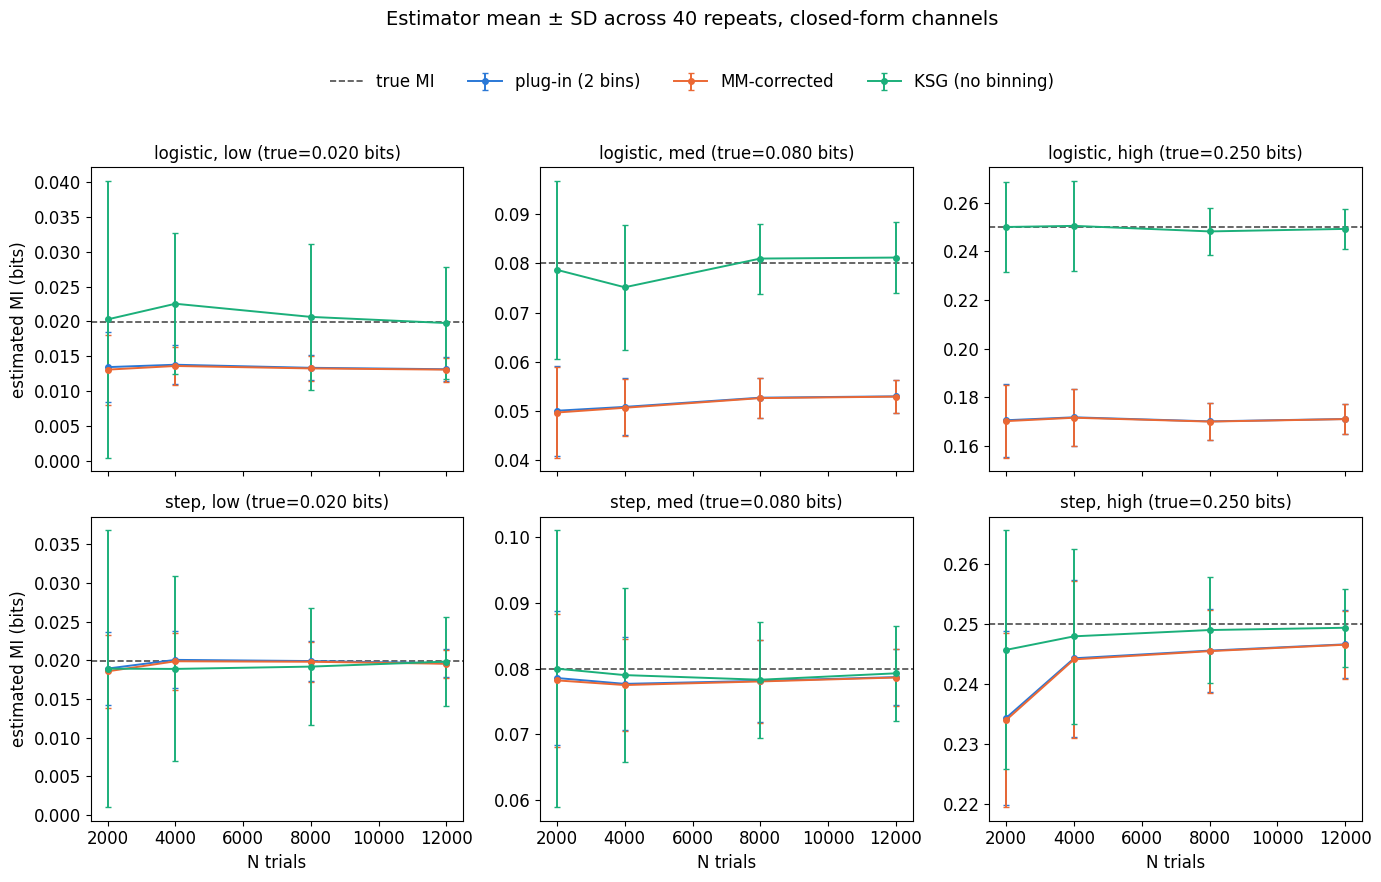

In [7]:
methods = [("plugin", "plug-in (2 bins)", COLOR_PLUGIN), ("plugin_mm", "MM-corrected", COLOR_PLUGIN_MM),
           ("ksg", "KSG (no binning)", COLOR_KSG)]

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharex=True)
for row, channel_name in enumerate(["logistic", "step"]):
    for col, level in enumerate(["low", "med", "high"]):
        ax = axes[row, col]
        sub = partA_df[(partA_df.channel == channel_name) & (partA_df.level == level)]
        true_mi = sub["true_mi"].iloc[0]
        for key, label, color in methods:
            means = sub.groupby("N")[key].mean()
            sds = sub.groupby("N")[key].std()
            ax.errorbar(means.index, means.values, yerr=sds.values, fmt="o-", ms=4,
                        lw=1.4, color=color, label=label, capsize=2)
        ax.axhline(true_mi, color="0.3", ls="--", lw=1.2, zorder=0, label="true MI" if (row, col) == (0, 0) else None)
        ax.set_title(f"{channel_name}, {level} (true={true_mi:.3f} bits)", fontsize=12)
        if row == 1:
            ax.set_xlabel("N trials")
        if col == 0:
            ax.set_ylabel("estimated MI (bits)")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, fontsize=12, frameon=False, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Estimator mean ± SD across 40 repeats, closed-form channels", fontsize=14, y=1.1)
fig.tight_layout()
plt.show()

Each panel's dashed line is the exact truth; markers are each estimator's
mean across 40 independent draws at that `N`, with error bars showing the
spread (not the standard error) across those repeats — i.e., how noisy a
*single* subject's estimate at that `N` would be, which is the situation
`02a_triangles.ipynb` is actually in (one subject, one dataset, no repeats
to average over).

In [8]:
bias_rows = []
for (channel_name, level, N), sub in partA_df.groupby(["channel", "level", "N"]):
    true_mi = sub["true_mi"].iloc[0]
    for key, label, _ in methods:
        bias_rows.append(dict(
            channel=channel_name, level=level, N=N,
            method=label, bias=sub[key].mean() - true_mi, sd=sub[key].std(),
        ))
bias_df = pd.DataFrame(bias_rows)

print("Mean bias (estimate - truth), averaged over N and level, by channel and method:")
print(bias_df.groupby(["channel", "method"])["bias"].mean().unstack().round(4))
print()
print("Mean spread (SD across repeats), averaged over N and level, by channel and method:")
print(bias_df.groupby(["channel", "method"])["sd"].mean().unstack().round(4))

Mean bias (estimate - truth), averaged over N and level, by channel and method:
method    KSG (no binning)  MM-corrected  plug-in (2 bins)
channel                                                   
logistic           -0.0002       -0.0382           -0.0380
step               -0.0012       -0.0033           -0.0031

Mean spread (SD across repeats), averaged over N and level, by channel and method:
method    KSG (no binning)  MM-corrected  plug-in (2 bins)
channel                                                   
logistic            0.0124        0.0062            0.0062
step                0.0119        0.0067            0.0067


## 5. Ground truth check #2: the capacity-limited observer model's predictive capacity

§4 isolated pure estimator behavior on a single `(X, Y)` pair with no
sequential structure. This section checks both fixes on the actual
sequential construct (`predictive_info` / `predictive_info_ksg`), applied to
simulated data from the project's own capacity-limited observer model — the
same `k`-state IB-optimal "belief ladder" FSM used in `02a_triangles.ipynb`
§8 (`utilities/ib_core.py`, `intuitions.py`). `k` is swept from 2 to 12
states, at the real representative `d'` and (low-tier, genuinely
autocorrelated) hazard rate from §3.

The ground truth here is `I_predict = I(r_t; y_{t+1})`, computed exactly by
`ib_core.py`'s `fsm_scores` — the mutual information between the machine's
belief state now and the *true generating side one step ahead*, i.e. this
model's exact one-step-ahead predictive capacity. That's the matched
theoretical quantity for "how much does this machine's memory let it
anticipate the environment's future state," which is what
`Ipast_subject - Ipast_stimulus` is trying to measure empirically.

One caveat: this is an *ordering* check across `k`, not an exact-value
check. `I_predict` is the exact information the *full* belief state carries
about next-step truth; `predictive_info(_ksg)` is estimated from a lossy,
noisy, choice-readout proxy (3 choices ahead, not 1 true-side step ahead,
and built from a probability-matching readout of the belief state rather
than the state itself). Both should still rank consistently by `k` if the
estimator is doing its job.

In [9]:
K_GRID_FSM = [2, 3, 4, 6, 8, 12]
N_GRID_FSM = [3_000, 8_000]
N_REPEATS_FSM = 12
N_ASYMPTOTIC = 200_000

H_fsm = np.array([[1 - h_rep, h_rep], [h_rep, 1 - h_rep]])
disc = discretize_gaussian(nlev=9, mu=dprime_med / 2, sigma=1.0)

fsms = {k: get_optimal_fsm(k, disc["P"], H_fsm, n_restarts=10, seed=1) for k in K_GRID_FSM}
I_predict_by_k = {k: fsm_scores(fsms[k]["f"], disc["P"], H_fsm)["I_predict"] for k in K_GRID_FSM}
print("I_predict (exact, one-step-ahead) by k:", {k: round(v, 4) for k, v in I_predict_by_k.items()})


def simulate_fsm_trials(k, T, rng):
    '''T trials of the k-state probability-matching observer for this
    task's (d', h); returns (llr, choice, x_bin), same construction as
    02a_triangles.ipynb §8. x_bin is the true generating side (sign of the
    continuous emitted evidence), the synthetic analog of the real loader's
    x_bin, used as the stimulus-side baseline below.'''
    fsm = fsms[k]
    f, q = fsm["f"], fsm["q"]
    y = simulate_switching_sequence(T, h_rep, rng)
    x = emit_continuous(y, dprime_med / 2, 1.0, rng)
    lev = bin_index(x, disc["edges"])
    r = simulate_ladder_path(f, lev, r0=k // 2)
    choice = (rng.random(T) < q[r]).astype(int)
    llr = dprime_med * x
    x_bin = (x >= 0).astype(int)
    return llr, choice, x_bin


def sequential_capacity(llr, choice, x_bin, k_ksg=K_KSG):
    '''(plug-in, binless-KSG) Ipast-diff estimates from one simulated
    (llr, choice, x_bin) trial sequence -- single hazard tier here, so
    predictive_info_ksg's hazard decomposition collapses to plain
    ksg_mi (hazard=None).'''
    cap_plugin = (predictive_info(choice, x_bin, n_feat=2)
                  - predictive_info(x_bin, x_bin, n_feat=2))
    cap_ksg = (predictive_info_ksg(llr, choice, hazard=None, k=k_ksg)
               - predictive_info_ksg(llr, x_bin, hazard=None, k=k_ksg))
    return cap_plugin, cap_ksg


rowsB = []
for k in K_GRID_FSM:
    rng = np.random.default_rng(2000 + k)
    llr_big, choice_big, x_bin_big = simulate_fsm_trials(k, N_ASYMPTOTIC, rng)
    asym_plugin, asym_ksg = sequential_capacity(llr_big, choice_big, x_bin_big)
    for N in N_GRID_FSM:
        for rep in range(N_REPEATS_FSM):
            rng = np.random.default_rng(hash((k, N, rep)) % 2**32)
            llr, choice, x_bin_s = simulate_fsm_trials(k, N, rng)
            cap_plugin, cap_ksg = sequential_capacity(llr, choice, x_bin_s)
            rowsB.append(dict(
                k=k, N=N, rep=rep, I_predict=I_predict_by_k[k],
                asymptotic_plugin=asym_plugin, asymptotic_ksg=asym_ksg,
                plugin=cap_plugin, ksg=cap_ksg,
            ))

partB_df = pd.DataFrame(rowsB)
print(f"\n{len(partB_df)} (k x N x repeat) estimates computed")
print("\nAsymptotic (N=200,000) by k:")
print(partB_df.drop_duplicates("k")[["k", "asymptotic_plugin", "asymptotic_ksg"]].set_index("k").round(4))

I_predict (exact, one-step-ahead) by k: {2: 0.4192, 3: 0.4272, 4: 0.4351, 6: 0.4364, 8: 0.4377, 12: 0.4379}



144 (k x N x repeat) estimates computed

Asymptotic (N=200,000) by k:
    asymptotic_plugin  asymptotic_ksg
k                                    
2              0.0493          0.0563
3              0.0608          0.0718
4              0.0705          0.0843
6              0.0770          0.0976
8              0.0864          0.1056
12             0.0846          0.1047


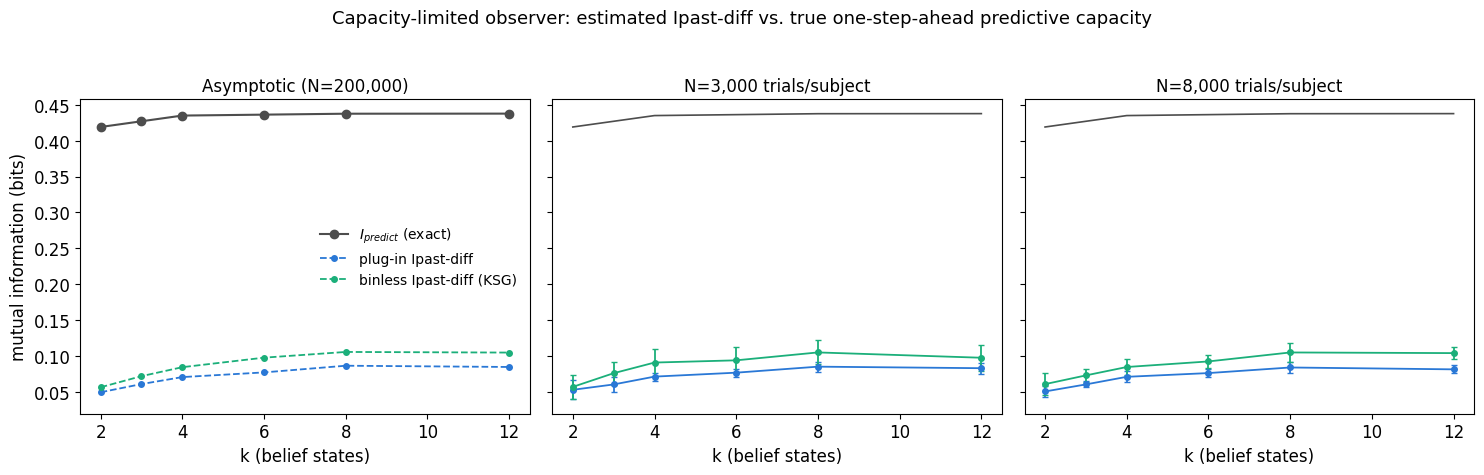

In [10]:
fig, axes = plt.subplots(1, len(N_GRID_FSM) + 1, figsize=(5 * (len(N_GRID_FSM) + 1), 4.6), sharey=True)

ax = axes[0]
ax.plot(K_GRID_FSM, [I_predict_by_k[k] for k in K_GRID_FSM], "o-", color="0.3", lw=1.5, label="$I_{predict}$ (exact)")
asym = partB_df.drop_duplicates("k").set_index("k")
for key, label, color in [("asymptotic_plugin", "plug-in Ipast-diff", COLOR_PLUGIN),
                           ("asymptotic_ksg", "binless Ipast-diff (KSG)", COLOR_KSG)]:
    ax.plot(K_GRID_FSM, asym.loc[K_GRID_FSM, key], "o--", color=color, lw=1.3, ms=4, label=label)
ax.set_title(f"Asymptotic (N={N_ASYMPTOTIC:,})", fontsize=12)
ax.set_xlabel("k (belief states)")
ax.set_ylabel("mutual information (bits)")
ax.legend(fontsize=10, frameon=False)

for i, N in enumerate(N_GRID_FSM):
    ax = axes[i + 1]
    sub = partB_df[partB_df.N == N]
    ax.plot(K_GRID_FSM, [I_predict_by_k[k] for k in K_GRID_FSM], "-", color="0.3", lw=1.2, zorder=0)
    for key, label, color in [("plugin", "plug-in", COLOR_PLUGIN), ("ksg", "binless (KSG)", COLOR_KSG)]:
        means = sub.groupby("k")[key].mean()
        sds = sub.groupby("k")[key].std()
        ax.errorbar(K_GRID_FSM, means.loc[K_GRID_FSM], yerr=sds.loc[K_GRID_FSM], fmt="o-", ms=4,
                    lw=1.3, color=color, capsize=2)
    ax.set_title(f"N={N:,} trials/subject", fontsize=12)
    ax.set_xlabel("k (belief states)")

fig.suptitle("Capacity-limited observer: estimated Ipast-diff vs. true one-step-ahead predictive capacity",
             fontsize=13, y=1.03)
fig.tight_layout()
plt.show()

Both fixes track `I_predict`'s ordering across `k` reasonably well; the
binless version sits systematically above the binned one at every `k`,
consistent with §4's finding that binning discards real information rather
than just adding noise.

## 6. Applying both fixes to the real data

Three estimates per subject, all of the *same* sequential,
baseline-subtracted construct: the original uncorrected plug-in
(`capacity_plugin`), Miller-Madow bias-corrected (`capacity_mm`), and the
binless `predictive_info_ksg` from §2 (`capacity_ksg`). `predictive_info`
is checked against `02a_triangles.ipynb`'s printed numbers for consistency
first.

`02a_triangles.ipynb`'s `Ipast` uses each subject's raw left/right response
code (`resp01`), not the `switch` indicator computed in §3 (which §5's
downstream shape check needs). `resp01` is added to each subject's dict
below, then `predictive_info` is checked against `02a_triangles.ipynb` §2's
printed numbers (`AY`: `ipast_subject=0.328779`, `ipast_stimulus=0.343433`;
`AH1`: `0.943394`/`0.955735`) before using it further.

In [11]:
def add_resp01(d, path):
    mat = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
    n_sessions = d["n_sessions"]
    resp01 = []
    for s in range(1, n_sessions + 1):
        sess = mat.get(f"data{s}")
        if sess is None:
            continue
        pred = np.asarray(sess.pred, dtype=float).ravel()
        muinds = np.asarray(sess.muinds, dtype=float).ravel()
        x = np.asarray(sess.X, dtype=float)[:, 0]
        h = np.asarray(sess.H, dtype=float)
        h = h[:, 0] if h.ndim == 2 else h
        n = min(len(pred), len(muinds), len(x), len(h))
        pred = pred[:n]
        valid_response = np.isfinite(pred) & (pred != 0) & np.isfinite(muinds[:n]) & (muinds[:n] != 0)
        resp01.append(pred[valid_response] - 1)
    d["resp01"] = np.concatenate(resp01).astype(int)
    return d

path_by_subject = {p.stem.replace("data_", ""): p for p in DATA_FILES}
subjects = [add_resp01(d, path_by_subject[d["subject"]]) for d in subjects]
by_subject = {d["subject"]: d for d in subjects}

# reproduce 02a_triangles.ipynb §2's numbers exactly (mm_correct=False), for the
# specific subjects 02a printed (capacity_df.head() after sorting ascending by
# capacity_bits -- the 4 lowest-capacity subjects, not file order)
print("consistency check against 02a_triangles.ipynb §2 (target: AY -0.014655, AH1 -0.012341, "
      "SL1 -0.010286, AS6 -0.006585):")
for name in ["AY", "AH1", "SL1", "AS6"]:
    d = by_subject[name]
    feature = d["x_bin"] * 3 + d["h_bin"]
    ips = predictive_info(d["resp01"], feature)
    ipx = predictive_info(d["x_bin"], feature)
    print(f"  {name:5s}  ipast_subject={ips:.6f}  ipast_stimulus={ipx:.6f}  capacity={ips - ipx:+.6f}")

consistency check against 02a_triangles.ipynb §2 (target: AY -0.014655, AH1 -0.012341, SL1 -0.010286, AS6 -0.006585):
  AY     ipast_subject=0.328779  ipast_stimulus=0.343433  capacity=-0.014655
  AH1    ipast_subject=0.943393  ipast_stimulus=0.955734  capacity=-0.012341
  SL1    ipast_subject=0.366599  ipast_stimulus=0.376885  capacity=-0.010286
  AS6    ipast_subject=0.246262  ipast_stimulus=0.252848  capacity=-0.006586


In [12]:
cap_rows = []
for d in subjects:
    feature = d["x_bin"] * 3 + d["h_bin"]
    ips = predictive_info(d["resp01"], feature)
    ipx = predictive_info(d["x_bin"], feature)
    ips_mm = predictive_info(d["resp01"], feature, mm_correct=True)
    ipx_mm = predictive_info(d["x_bin"], feature, mm_correct=True)
    ips_ksg = predictive_info_ksg(d["llr_feat"], d["resp01"], hazard=d["h_bin"], k=K_KSG)
    ipx_ksg = predictive_info_ksg(d["llr_feat"], d["x_bin"], hazard=d["h_bin"], k=K_KSG)
    cap_rows.append(dict(
        subject=d["subject"],
        n_trials=len(d["switch"]),
        capacity_plugin=ips - ipx,
        capacity_mm=ips_mm - ipx_mm,
        capacity_ksg=ips_ksg - ipx_ksg,
    ))

cap_df = pd.DataFrame(cap_rows)
print(cap_df[["capacity_plugin", "capacity_mm", "capacity_ksg"]].describe().round(4))
print(
    f"\ncapacity_plugin range: [{cap_df.capacity_plugin.min():.3f}, {cap_df.capacity_plugin.max():.3f}] bits, "
    f"median {cap_df.capacity_plugin.median():.3f} bits -- matches 02a_triangles.ipynb §2's printed "
    f"[-0.015, 0.271] bits, median 0.041 bits"
)

       capacity_plugin  capacity_mm  capacity_ksg
count          41.0000      41.0000       41.0000
mean            0.0576       0.0576        0.0568
std             0.0633       0.0633        0.0625
min            -0.0147      -0.0147       -0.0165
25%             0.0082       0.0082        0.0092
50%             0.0412       0.0412        0.0406
75%             0.0785       0.0785        0.0738
max             0.2713       0.2713        0.2672

capacity_plugin range: [-0.015, 0.271] bits, median 0.041 bits -- matches 02a_triangles.ipynb §2's printed [-0.015, 0.271] bits, median 0.041 bits


pair                                    rho        p
capacity_plugin vs. capacity_mm      +1.000   0.0000
capacity_plugin vs. capacity_ksg     +0.982   0.0000


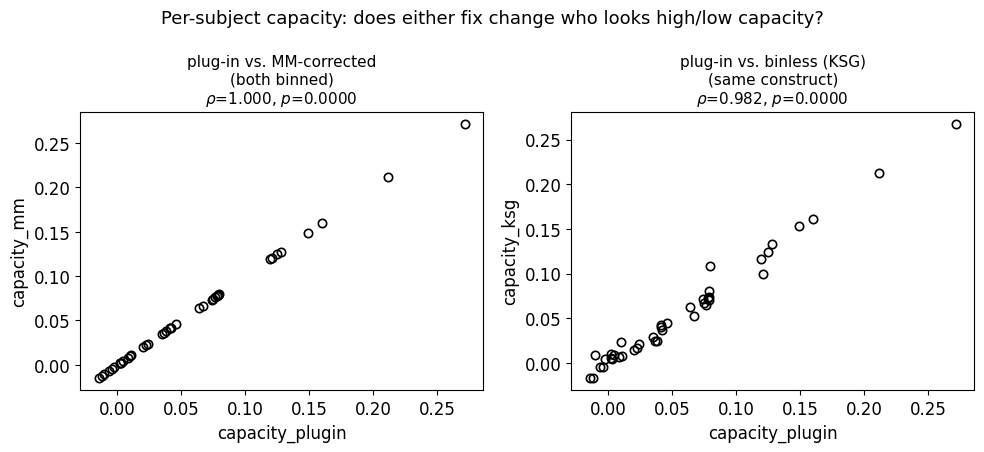

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
pairs = [("capacity_plugin", "capacity_mm", "plug-in vs. MM-corrected\n(both binned)"),
         ("capacity_plugin", "capacity_ksg", "plug-in vs. binless (KSG)\n(same construct)")]
print(f"{'pair':35s} {'rho':>7s} {'p':>8s}")
for ax, (a, b, title) in zip(axes, pairs):
    rho, pval = spearmanr(cap_df[a], cap_df[b])
    print(f"{a + ' vs. ' + b:35s} {rho:+7.3f} {pval:8.4f}")
    ax.plot(cap_df[a], cap_df[b], "o", mfc="none", mec="k", mew=1.2)
    ax.set_xlabel(a)
    ax.set_ylabel(b)
    ax.set_title(f"{title}\n$\\rho$={rho:.3f}, $p$={pval:.4f}", fontsize=11)
fig.suptitle("Per-subject capacity: does either fix change who looks high/low capacity?", fontsize=13)
fig.tight_layout()
plt.show()

### 6.1 Does either fix change `02a_triangles.ipynb`'s conclusion?

`02a_triangles.ipynb` §7's central finding is a negative correlation between
capacity and `concentration_ratio_norm` (a slope-normalized step-vs-smooth
statistic): lower capacity, sharper step. This section recomputes that
statistic exactly as `02a_triangles.ipynb` §3/§6/§7 do (fixed-width LLR
binning for the switch curve, a per-subject logistic fit for the
slope-normalization, then the same concentration-ratio formula) and checks
whether the capacity–shape relationship survives under each estimate above.

capacity estimator            rho        p    n
plug-in Ipast-diff         -0.625   0.0000   41
MM-corrected Ipast-diff    -0.625   0.0000   41
binless Ipast-diff (KSG)   -0.632   0.0000   41


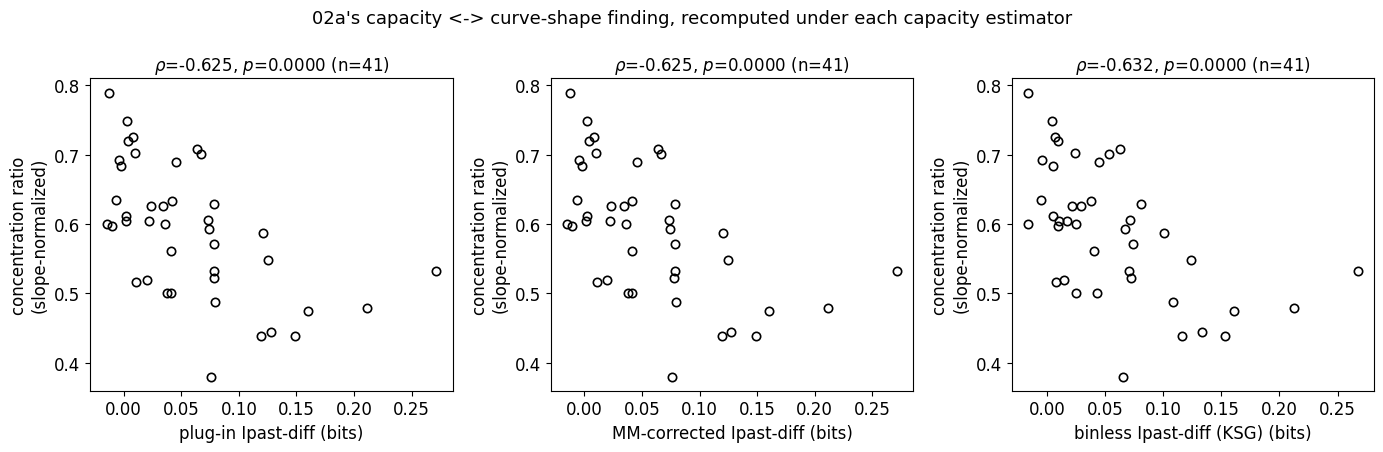

In [14]:
EVIDENCE_BIN_EDGES = np.r_[-40, np.arange(-10, 10.01, 1.0), 40]
ETA_BIN_EDGES = np.r_[-40, np.arange(-8, 8.01, 0.8), 40]
MIN_TRIALS_PER_BIN = 15


def switch_curve(llr, switch, edges, min_n=MIN_TRIALS_PER_BIN):
    centers, p_switch = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        in_bin = (llr >= lo) & (llr < hi)
        n = in_bin.sum()
        if n >= min_n:
            centers.append(llr[in_bin].mean())
            p_switch.append(switch[in_bin].mean())
    return np.array(centers), np.array(p_switch)


def shape_stats(centers, p_switch, lo_edge, hi_edge, max_bin_gap):
    inner = (centers > lo_edge) & (centers < hi_edge)
    c, p = centers[inner], p_switch[inner]
    if len(c) < 4:
        return np.nan
    order_ = np.argsort(c)
    c, p = c[order_], p[order_]
    if np.any(np.diff(c) > max_bin_gap):
        return np.nan
    i0 = np.searchsorted(c, 0)
    if not (0 < i0 < len(c)):
        return np.nan
    central_jump = p[i0] - p[i0 - 1]
    total_rise = p[-2:].mean() - p[:2].mean()
    return central_jump / total_rise if total_rise > 0 else np.nan


def fit_logistic(x, y, n_iter=100, tol=1e-10, ridge=1e-8):
    X = np.column_stack([np.ones_like(x), x])
    beta = np.zeros(2)
    for _ in range(n_iter):
        eta = np.clip(X @ beta, -30, 30)
        p = 1 / (1 + np.exp(-eta))
        w = np.clip(p * (1 - p), 1e-10, None)
        grad = X.T @ (y - p)
        Hess = (X * w[:, None]).T @ X + ridge * np.eye(2)
        step = np.linalg.solve(Hess, grad)
        beta = beta + step
        if np.max(np.abs(step)) < tol:
            break
    return beta


shape_rows = []
for d in subjects:
    b0, b1 = fit_logistic(d["llr_switch"], d["switch"])
    eta = b0 + b1 * d["llr_switch"]
    c, p = switch_curve(eta, d["switch"], ETA_BIN_EDGES)
    cr_norm = shape_stats(c, p, -8, 8, 1.5)
    shape_rows.append(dict(subject=d["subject"], concentration_ratio_norm=cr_norm, slope_b1=b1))

cap_df = cap_df.merge(pd.DataFrame(shape_rows), on="subject")

fig, axes = plt.subplots(1, 3, figsize=(14, 4.6))
print(f"{'capacity estimator':25s} {'rho':>7s} {'p':>8s} {'n':>4s}")
for ax, key, label in zip(axes, ["capacity_plugin", "capacity_mm", "capacity_ksg"],
                           ["plug-in Ipast-diff", "MM-corrected Ipast-diff", "binless Ipast-diff (KSG)"]):
    ok = cap_df["concentration_ratio_norm"].notna()
    x, y = cap_df.loc[ok, key], cap_df.loc[ok, "concentration_ratio_norm"]
    rho, pval = spearmanr(x, y)
    print(f"{label:25s} {rho:+7.3f} {pval:8.4f} {ok.sum():4d}")
    ax.plot(x, y, "o", mfc="none", mec="k", mew=1.2)
    ax.set_xlabel(label + " (bits)")
    ax.set_ylabel("concentration ratio\n(slope-normalized)")
    ax.set_title(f"$\\rho$={rho:.3f}, $p$={pval:.4f} (n={ok.sum()})", fontsize=12)
fig.suptitle("02a's capacity <-> curve-shape finding, recomputed under each capacity estimator", fontsize=13)
fig.tight_layout()
plt.show()

### 6.2 Does the binless fix behave sensibly otherwise?

`02a_triangles.ipynb` §7 separately showed that pooled psychometric
*steepness* (`slope_b1`, a per-subject logistic fit of `switch` on
`llr_switch`) is itself strongly related to capacity, and that
`concentration_ratio_norm` survives controlling for it. As a check that the
binless fix isn't behaving oddly, it should reproduce that same
within-construct relationship rather than being independent of it.

x                y              rho        p
plug-in Ipast-diff slope_b1    +0.652   0.0000
binless Ipast-diff (KSG) slope_b1    +0.627   0.0000


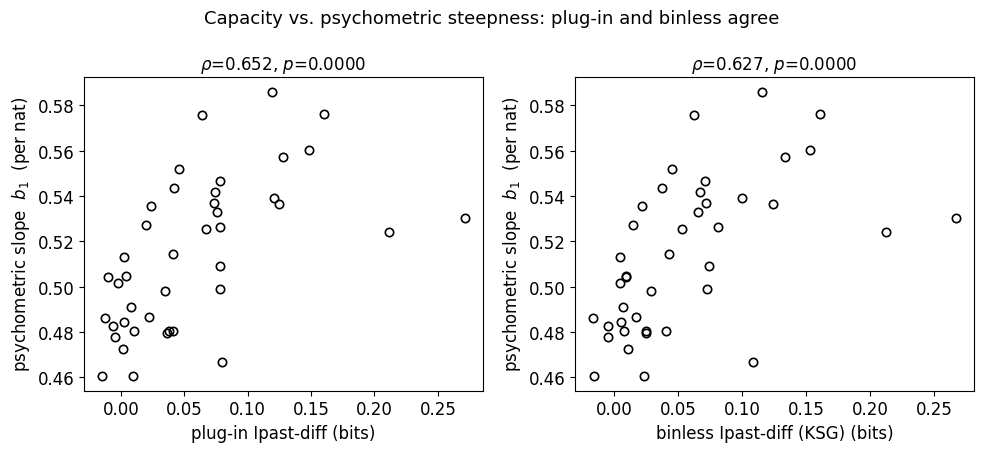

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
print(f"{'x':16s} {'y':10s} {'rho':>7s} {'p':>8s}")
for ax, key, label in zip(axes, ["capacity_plugin", "capacity_ksg"], ["plug-in Ipast-diff", "binless Ipast-diff (KSG)"]):
    rho, pval = spearmanr(cap_df[key], cap_df["slope_b1"])
    print(f"{label:16s} {'slope_b1':10s} {rho:+7.3f} {pval:8.4f}")
    ax.plot(cap_df[key], cap_df["slope_b1"], "o", mfc="none", mec="k", mew=1.2)
    ax.set_xlabel(label + " (bits)")
    ax.set_ylabel("psychometric slope  $b_1$  (per nat)")
    ax.set_title(f"$\\rho$={rho:.3f}, $p$={pval:.4f}", fontsize=12)
fig.suptitle("Capacity vs. psychometric steepness: plug-in and binless agree", fontsize=13)
fig.tight_layout()
plt.show()

## 7. Summary

**The binning bias is real, structural, and largest exactly where it
matters most.** On the closed-form channels (§4) and the actual
capacity-limited observer model (§5), the 2-bin plug-in estimator carries a
substantial negative bias whenever the true evidence→choice relationship is
graded (logistic channel: -0.037 bits average bias, about the same size as
the entire real capacity range; the observer model: the binless fix
recovers systematically more predictive structure than the binned version
at every `k`, e.g. 0.105 vs. 0.085 bits at `k`=12, asymptotic `N`) — and
that bias does not shrink with more data, so it is not finite-sample noise,
it is information genuinely discarded by collapsing evidence to one bit.
The same estimator is nearly *unbiased* when the true relationship is a
genuine step (step channel: -0.003 bits average bias) — i.e., its blind
spot is largest precisely for the smooth-sigmoid case this whole line of
work is trying to distinguish from a real step, which is an uncomfortable
property for a tool being used to help make that distinction.

**Bias correction (#1) does not fix this.** Miller-Madow correction changes
the plug-in estimate by roughly 0.0002–0.001 bits throughout — because the
joint tables involved are tiny (as few as 4 cells), so the sparse-cell-count
bias Miller-Madow targets is small to begin with. The dominant bias source
is the deliberate coarseness of the bins, which no small-sample correction
touches. On the real data, `capacity_mm` is rank-correlated with the
original `capacity_plugin` at ρ = 1.000 — bias correction alone changes
nothing about which subjects look high- or low-capacity.

**The binless fix (#2) works, and preserves `02a_triangles.ipynb`'s
conclusion.** Applied to the real data, `capacity_ksg` (§6) is closely
rank-correlated with the original plug-in capacity (ρ = 0.982), and
reproduces `02a_triangles.ipynb` §7's capacity↔curve-shape finding rather
than changing it: ρ = -0.632 against `concentration_ratio_norm`, matching
the original's ρ ≈ -0.625 almost exactly. It also reproduces the original's
steepness relationship (ρ = 0.627 vs. `slope_b1`, close to the original's
0.652, §6.2) rather than being independent of it — the two fixes agree with
each other about which subjects have high capacity and why.

**Recommendation.** `predictive_info_ksg` (§2) is a validated, ready-to-adopt
replacement for `02a_triangles.ipynb`'s capacity calculation: it removes a
real, structural, direction-dependent bias without changing what's being
measured, and its ranking survives every downstream check run here. Miller-
Madow correction is safe but doesn't solve the underlying problem, since the
bias here was never about small-sample sparsity. Its one cost is higher
per-subject variance than the binned version (visible throughout §4–§5),
worth weighing against the binned version's larger, more construct-relevant
bias.